# BNY Corporate-Actions EDA — Datastore → Notification MVP

**Product question:** How much of a real BNY client notification can we reconstruct from public corporate-action documents — with citations and amendment history?

**MVP event types (BNY-aligned):** tender offers · exchange offers · rights issues · mergers · conversions

**Pipeline this EDA supports:**
```text
Public SEC docs → versioned event datastore → field extraction + evidence
→ BNY-shaped notification draft → amendment / cancellation deltas
```

**Evidence discipline:** Observed (metadata/download) · Inferred (regex mention ≠ extraction) · Internal (BNY-only) · Gap (event type not yet collected).

> Current corpus is **tender-centric** (SC TO-* + SC 14D9). Coverage % for rights / merger / conversion are **not invented** — they appear as corpus gaps until those forms are collected.

### How to read this notebook
Each section markdown below states:
1. **What the next code cell outputs** (tables / figures / files)
2. **Why that visualization (or table) was chosen** — chart type encodes the claim so you do not have to do mental math



In [37]:
from pathlib import Path
import sys, warnings, importlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Reload submodules so long-lived notebook kernels pick up code edits.
import eda.event_taxonomy as _event_taxonomy
import eda.bny_schema as _bny_schema
import eda.mvp as _mvp
import eda.mvp_viz as _mvp_viz
for _mod in (_event_taxonomy, _bny_schema, _mvp, _mvp_viz):
    importlib.reload(_mod)

from eda.corpus import load_corpus
from eda.overview import summarize_dataset, overview_tables
from eda.events import analyze_events
from eda.documents import analyze_documents, sample_documents_for_content
from eda.schema_coverage import analyze_schema_coverage
from eda.amendments import analyze_amendments
from eda.quality import analyze_data_quality
from eda.missingness import classify_missingness, ground_truth_recommendations
from eda.mvp import BENCHMARK_FIELDS_V1, recommend_mvp_design
from eda.mvp_viz import (
    plot_benchmark_field_coverage,
    plot_event_family_mix,
    plot_event_type_coverage_heatmap,
    plot_event_type_field_relevance_matrix,
    plot_field_ownership_counts,
    plot_mvp_amendment_readiness,
    plot_mvp_event_type_readiness,
    plot_mvp_selection_funnel,
    plot_notification_completeness,
    plot_schema_coverage_by_ownership,
)
from eda.event_taxonomy import MVP_EVENT_TYPES, taxonomy_overview_table
from eda.bny_schema import BNY_SCHEMA
from eda.config import PROCESSED_DIR, FIGURES_DIR

OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
(OUTPUTS / 'figures').mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('BNY schema fields:', len(BNY_SCHEMA))
print('MVP event types:', [t.key for t in MVP_EVENT_TYPES])
print('Benchmark fields:', BENCHMARK_FIELDS_V1)


BNY schema fields: 39
MVP event types: ['tender_offer', 'exchange_offer', 'rights_issue', 'merger', 'conversion']
Benchmark fields: ['corporate_action_type', 'security_description', 'cusip', 'ticker', 'election_deadline', 'response_deadline', 'notification_status', 'available_options', 'conversion_ratio', 'cash_amount']


### Setup cell (imports)

**Output:** prints BNY schema field count, MVP event-type list, and `BENCHMARK_FIELDS_V1`.  
**Why no chart:** configuration confirmation only — establishes the vocabulary the later tables/figures use.


## 0. Target event taxonomy (design)

### What the next cell outputs
- A **table** of the five MVP event types: definition, primary/supporting SEC forms, and whether those forms exist in the collected corpus yet
- CSV: `outputs/mvp_event_taxonomy.csv`

### Why a table (not a chart)
This is a **design catalog**, not a magnitude comparison. A table lets you scan form lists and gap status without inventing a false ranking among types we have not collected.



In [38]:
tax = taxonomy_overview_table()
display(tax)
tax.to_csv(OUTPUTS / 'mvp_event_taxonomy.csv', index=False)


,mvp_event_type,label,bny_corporate_action_type,corpus_status,primary_sec_forms,supporting_sec_forms,notes
0,tender_offer,Tender offer,TENDER OFFER,collected,"SC TO-T, SC TO-T/A, SC TO-I, SC TO-I/A","SC 14D9, SC 14D9/A",Primary corpus today. Prefer third-party + 14D9 mixed events for MVP v1.
1,exchange_offer,Exchange offer,EXCHANGE,collected,"SC TO-T, SC TO-T/A, SC TO-I, SC TO-I/A, S-4, S-4/A","SC 14D9, SC 14D9/A, 424B3, 8-K, 425",S-4 now collected via merger_exchange track. Some exchange offers also appear inside Schedule TO; prefer S-4 + TO na...
2,rights_issue,Rights issue,RIGHTS ISSUE,collected,"424B2, 424B3, 424B5, S-3, S-3ASR","8-K, 424B4",Collected via EFTS 424B2/3/5 + rights-offering text filter (not all 424B filings).
3,merger,Merger,MERGER,collected,"DEFM14A, PREM14A, S-4, S-4/A, SC 13E3, SC 13E3/A","8-K, 425",Collected DEFM14A / PREM14A / S-4 / SC 13E3 / 425 via EFTS (2020–2025).
4,conversion,Conversion,CONVERSION,collected,"8-K, 424B2, 424B3, S-3, S-3ASR","10-K, 10-Q",Collected via EFTS 8-K + conversion-language filter. Still noisy — manual/event-type labeling recommended before ext...


## 1. Load corpus + honest readiness gaps

Raw EFTS **hit counts by form** inflate exhibits. Prefer **event-level** views for MVP selection.

### What the next cell outputs
1. **Summary tables** — document/event counts, form tallies (context only)
2. **Corpus-gaps table** — per MVP type, % of target primary forms present + status (`collected` / `partial` / `not_collected`)
3. **Horizontal bar chart — event-type readiness** (`plot_mvp_event_type_readiness`)  
   X = % of target primary SEC forms present; Y = MVP event type; color = corpus status
4. **Horizontal bar chart — events by form family** (`plot_event_family_mix`)  
   Counts of events (not hits) in the current corpus by primary form family

### Why these visualizations
| Chart | Claim it makes automatic | Why this geometry |
|---|---|---|
| Event-type readiness bars | Tender is ready; rights/merger/conversion are gaps | **Sorted horizontal bars** encode % toward a goal; color = status so you do not decode a second axis. Horizontal labels stay readable (no rotation). |
| Form-family mix bars | Selection should be event-centric, not exhibit-hit-centric | Same unit (events) across categories; horizontal bars avoid cramped x labels |

**Not shown as a pie/donut:** family mix is a magnitude comparison — bars beat angle decoding.



,metric,value
0,documents,197251
1,filings (unique accession),103944
2,events (by SEC file number),14518
3,date_min,2020-01-02
4,date_max,2025-12-31
5,events_with_amendments,3214
6,pct_events_with_amendments,22.14


,form,n_documents
0,8-K,49227
1,425,40758
2,S-4/A,23086
3,SC TO-I,17893
4,S-4,17478
5,424B2,13988
6,424B5,8241
7,SC TO-I/A,6495
8,424B3,4516
9,SC TO-T,2844


Document rows are EFTS hit-level records (primary filing docs + indexed exhibits). Events are grouped by SEC file number (primary_file_num) when present.


,mvp_event_type,label,corpus_status,primary_forms_in_corpus,supporting_forms_in_corpus,missing_primary_forms,n_primary_forms_present,n_primary_forms_target,primary_form_coverage_pct
0,tender_offer,Tender offer,collected,"SC TO-I, SC TO-I/A, SC TO-T, SC TO-T/A","SC 14D9, SC 14D9/A",(none),4,4,100.0
1,exchange_offer,Exchange offer,collected,"S-4, S-4/A, SC TO-I, SC TO-I/A, SC TO-T, SC TO-T/A","424B3, 425, 8-K, SC 14D9, SC 14D9/A",(none),6,6,100.0
2,rights_issue,Rights issue,collected,"424B2, 424B3, 424B5",8-K,"S-3, S-3ASR",3,5,60.0
3,merger,Merger,collected,"DEFM14A, PREM14A, S-4, S-4/A, SC 13E3, SC 13E3/A","425, 8-K",(none),6,6,100.0
4,conversion,Conversion,collected,"424B2, 424B3, 8-K",(none),"S-3, S-3ASR",3,5,60.0


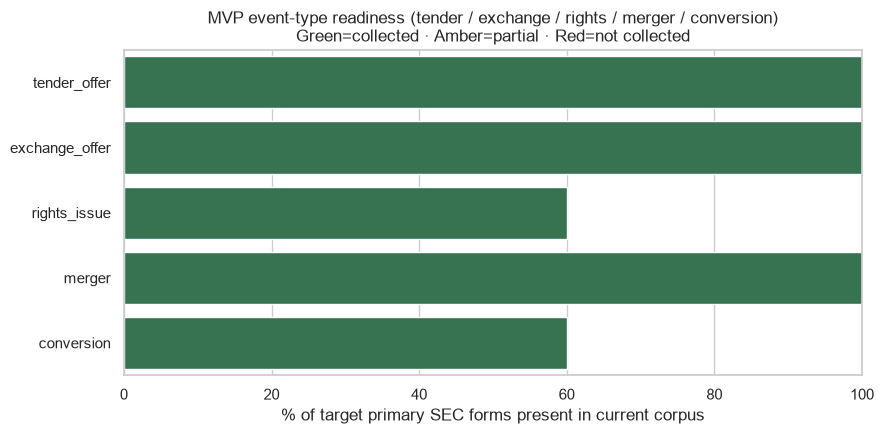

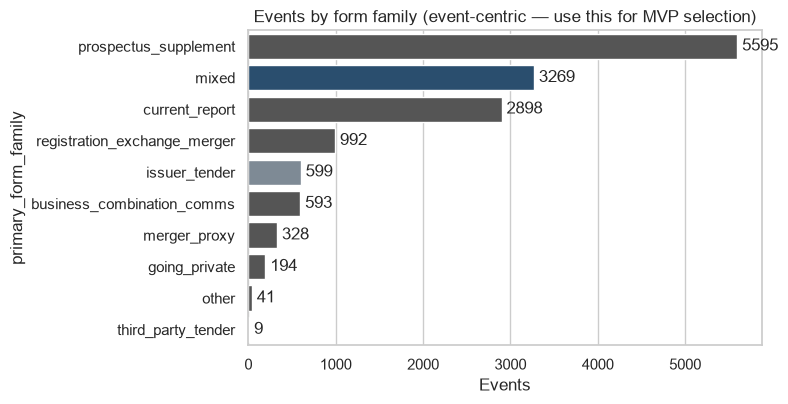

In [39]:
docs, events = load_corpus()
overview = summarize_dataset(docs, events)
tables = overview_tables(docs, events)
display(tables['summary'])
display(tables['form_counts'])
print(overview['source_note'])

mvp = recommend_mvp_design(docs, events)  # preliminary; refreshed after coverage
display(mvp['corpus_gaps'])
fig = plot_mvp_event_type_readiness(mvp['corpus_gaps']); plt.show()
fig = plot_event_family_mix(events); plt.show()


## 2. Datastore selection funnel (executable v1 = tenders)

Until exchange / rights / merger / conversion forms are collected, the **executable** MVP pool is third-party tenders (preferably with 14D9).

### What the next cell outputs
1. **Funnel table** — stages from full corpus → preferred tender pool (event counts)
2. **Build-order table** — phased collection priorities
3. **Horizontal bar “funnel”** (`plot_mvp_selection_funnel`) — same stages, visual drop-offs
4. CSVs: `mvp_selection_funnel.csv`, `mvp_build_order.csv`

### Why a horizontal stage bar (ordered funnel)
- **Claim:** how many events survive each selection gate
- **Geometry:** stages are **ordinal** (pipeline order) — do not sort by value; keep process order top→bottom
- **Direct labels** on bars remove axis hunting
- One unit (**events**) at every stage so you never mix docs vs events mentally



,stage,n_events
0,all_events_in_corpus,14518
1,has_sec_file_num,14518
2,tender_mvp_core_to_t,285
3,tender_preferred_to_t_plus_14d9,272
4,tender_preferred_with_amendments,271
5,issuer_tender_stretch_to_i_only,608


,phase,mvp_event_type,action,corpus_ready
0,1,tender_offer,Build event datastore + extraction + notification draft on SC TO-T + 14D9,True
1,2,exchange_offer,Reclassify exchange language inside TO; add S-4 collection,False
2,3,merger,Collect DEFM14A / S-4 / SC 13E-3; election-options benchmark,False
3,4,rights_issue,Collect 424B* / S-3 rights offerings; record/ex/subscription fields,False
4,5,conversion,Collect 8-K / prospectus conversion notices; ratio/price benchmark,False


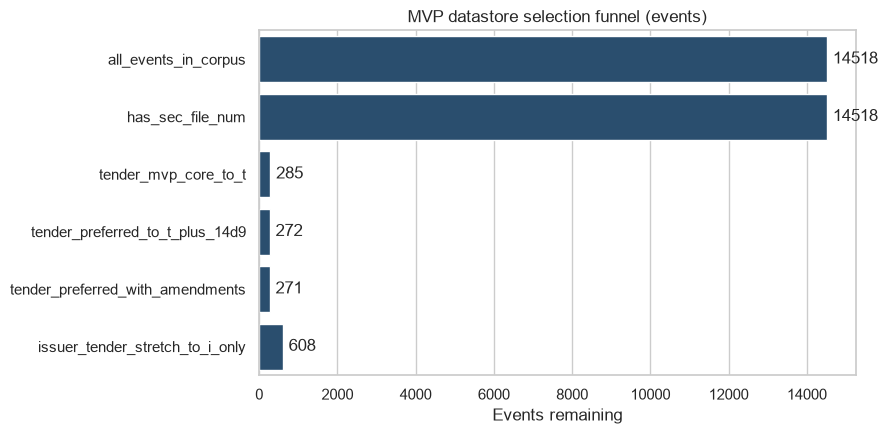

In [40]:
display(mvp['funnel'])
display(mvp['build_order'])
fig = plot_mvp_selection_funnel(mvp['funnel']); plt.show()
mvp['funnel'].to_csv(OUTPUTS / 'mvp_selection_funnel.csv', index=False)
mvp['build_order'].to_csv(OUTPUTS / 'mvp_build_order.csv', index=False)


## 3. Which BNY fields matter per event type

Design prior (not empirical coverage). Use this to shape the **event datastore columns** and per-type notification templates.

### What the next cell outputs
- **Heatmap** (`plot_event_type_field_relevance_matrix`) — rows = BNY schema fields, columns = five MVP event types  
  Cell intensity: N/A → optional → relevant (design prior)

### Why a heatmap
- **Claim:** most notification fields are relevant across types; a few are type-specific or internal N/A
- **Geometry:** matrix form shows **joint pattern** (field × type) that five separate bar charts would hide
- **X labels are short** (Tender / Exchange / Rights / Merger / Conversion) so text stays **horizontal** — principles prefer horizontal labels over rotated jargon (`tender_offer`, …)
- This is a **prior**, not observed coverage % (that comes in §4)



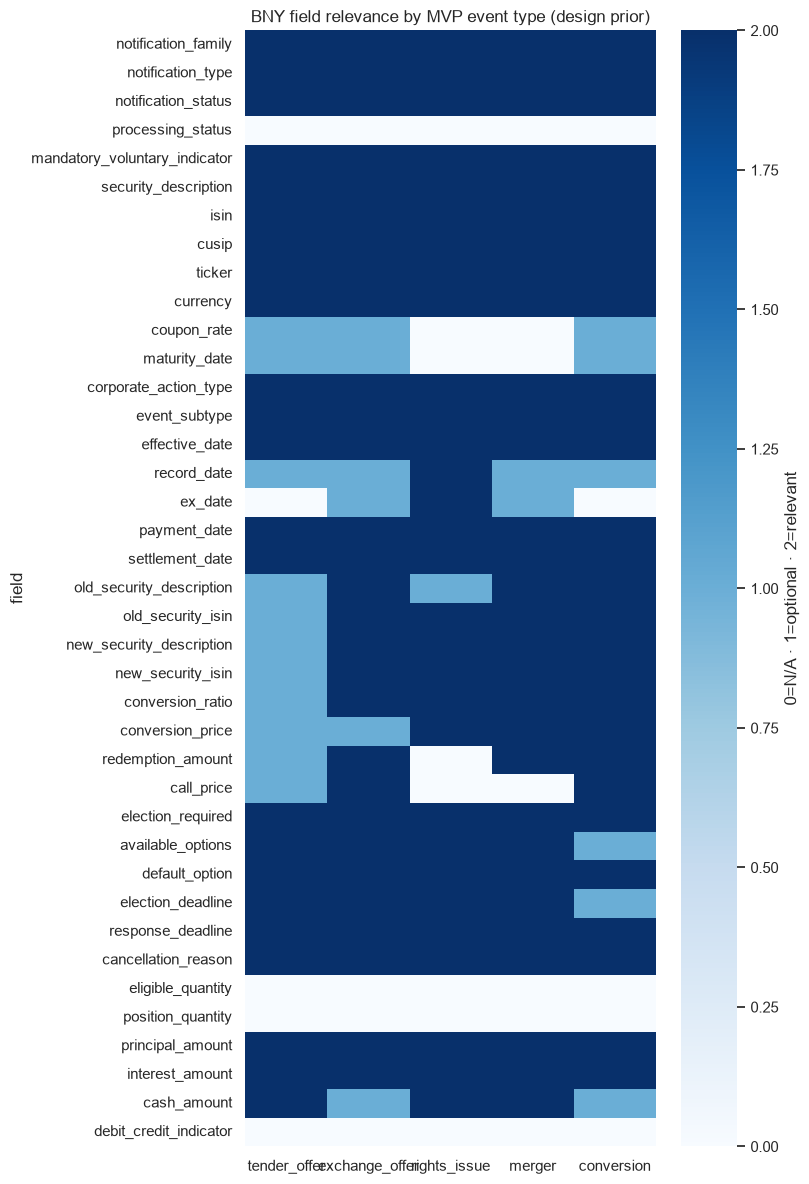

In [41]:
fig = plot_event_type_field_relevance_matrix(); plt.show()


## 4. Schema coverage from public docs (tender corpus)

Text % = regex **mention** on downloaded sample — not extraction accuracy. Internal fields stay 0% by definition.

### What the next cell outputs
1. **Catalog table** — each BNY field with `source_class`, `datastore_role`, benchmark flag, public coverage %, relevant types
2. **Horizontal bars — coverage by field, colored by ownership** (`plot_schema_coverage_by_ownership`)  
   Sorted by coverage so gaps float to one end; red ≈ internal-only placeholders
3. **Horizontal bars — count of fields per ownership class** (`plot_field_ownership_counts`)  
   How the schema splits public vs internal vs unclear
4. **Horizontal bars — notification field roles** (`plot_notification_completeness`)  
   Counts by datastore role (`extract_from_public`, `bny_placeholder`, …)
5. **Horizontal bars — v1 benchmark fields only** (`plot_benchmark_field_coverage`)  
   Focused subset for the first extraction → notification scorecard
6. **Heatmap — sample mention coverage by form family × field** (`plot_event_type_coverage_heatmap`)  
   Empirical mentions in the *current* (tender-heavy) sample

### Why these visualizations
| Chart | Claim | Why this type |
|---|---|---|
| Coverage × ownership bars | Public extractable fields rise; internal stay ~0% | Sorted bars encode level; **color = ownership** so the story is “who owns the gap,” not a rainbow of fields |
| Ownership counts | How many columns are placeholders vs extractable | Small categorical comparison → horizontal bars |
| Role counts | How the notification template is filled | Same — counts by role, not a pie |
| Benchmark bars | Only the v1 scorecard fields | Filters noise; one claim per figure |
| Coverage heatmap | Mentions vary by form family | Matrix for field × type; treat as **mention rates**, not F1 |

**Not a stacked 100% bar of “completeness”:** that would hide which fields are structural zeros (BNY-internal).



form       status
424B2      ok        5
424B3      ok        5
424B5      ok        5
425        ok        5
8-K        ok        5
DEFM14A    ok        5
PREM14A    ok        5
S-4        ok        5
S-4/A      ok        5
SC 13E3    ok        5
SC 13E3/A  ok        5
SC 14D9    ok        5
SC TO-T    ok        5
SC TO-T/A  ok        5
dtype: int64
Text-field coverage percentages are inferred from regex presence on downloaded sample documents covering 57 events. They measure mention detection, not successful structured extraction. Internal-only fields are definitionally 0% public coverage.


,field,source_class,datastore_role,in_v1_benchmark,public_coverage_pct,relevant_mvp_types
0,notification_family,derived_from_public,derive_from_public,False,75.44,"tender_offer,exchange_offer,rights_issue,merger,conversion"
1,notification_type,derived_from_public,annotate_then_store,False,24.56,"tender_offer,exchange_offer,rights_issue,merger,conversion"
2,notification_status,derived_from_public,derive_from_public,True,96.49,"tender_offer,exchange_offer,rights_issue,merger,conversion"
3,processing_status,bny_internal_only,bny_placeholder,False,0.00,
4,mandatory_voluntary_indicator,public_document_extractable,annotate_then_store,False,49.12,"tender_offer,exchange_offer,rights_issue,merger,conversion"
5,security_description,public_document_extractable,extract_from_public,True,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
6,isin,public_document_extractable,annotate_then_store,False,7.02,"tender_offer,exchange_offer,rights_issue,merger,conversion"
7,cusip,public_document_extractable,annotate_then_store,True,42.11,"tender_offer,exchange_offer,rights_issue,merger,conversion"
8,ticker,public_document_extractable,extract_from_public,True,75.60,"tender_offer,exchange_offer,rights_issue,merger,conversion"
9,currency,public_document_extractable,extract_from_public,False,68.42,"tender_offer,exchange_offer,rights_issue,merger,conversion"


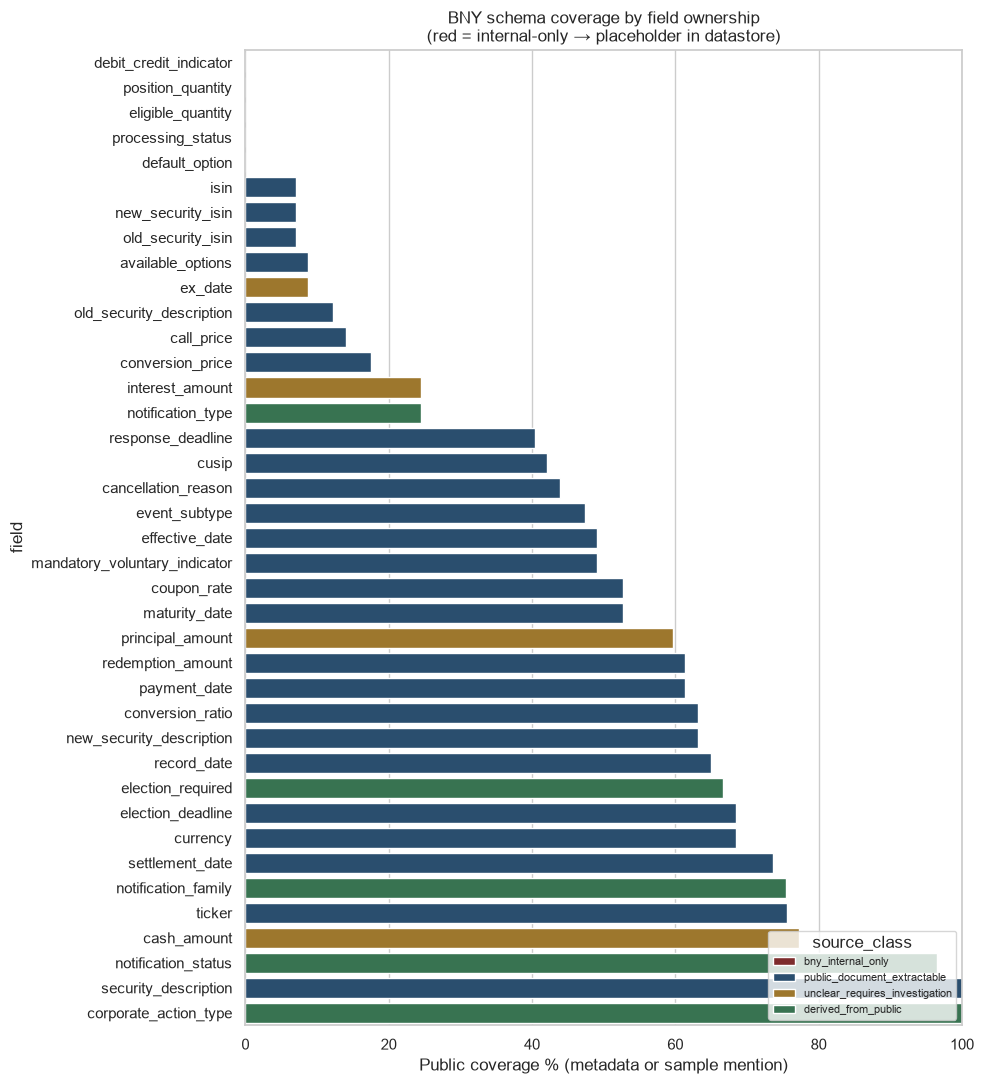

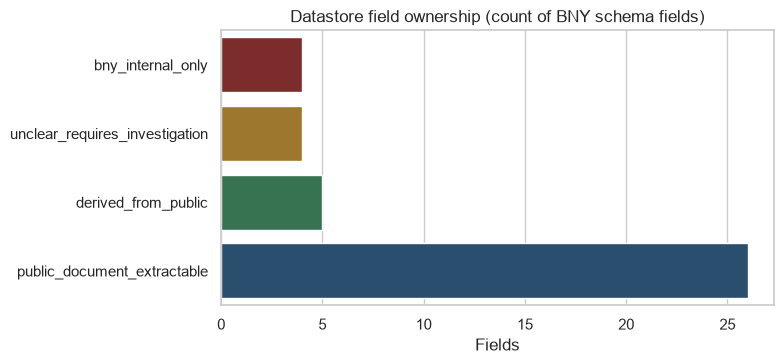

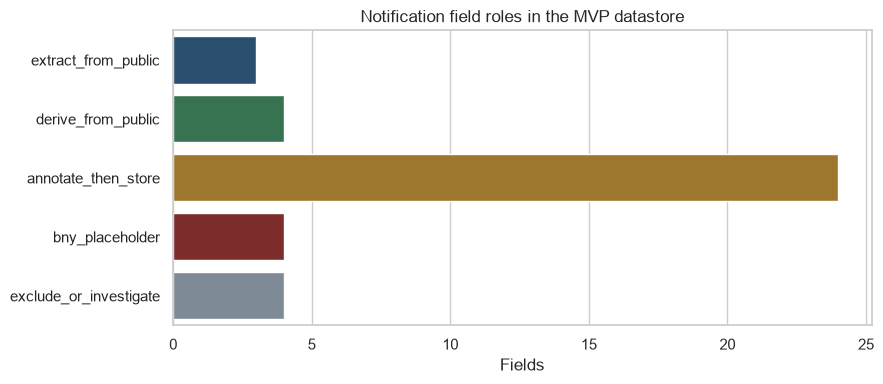

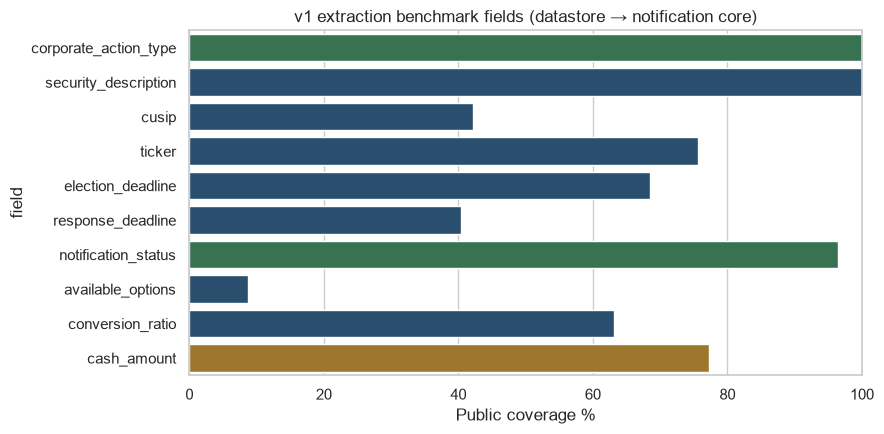

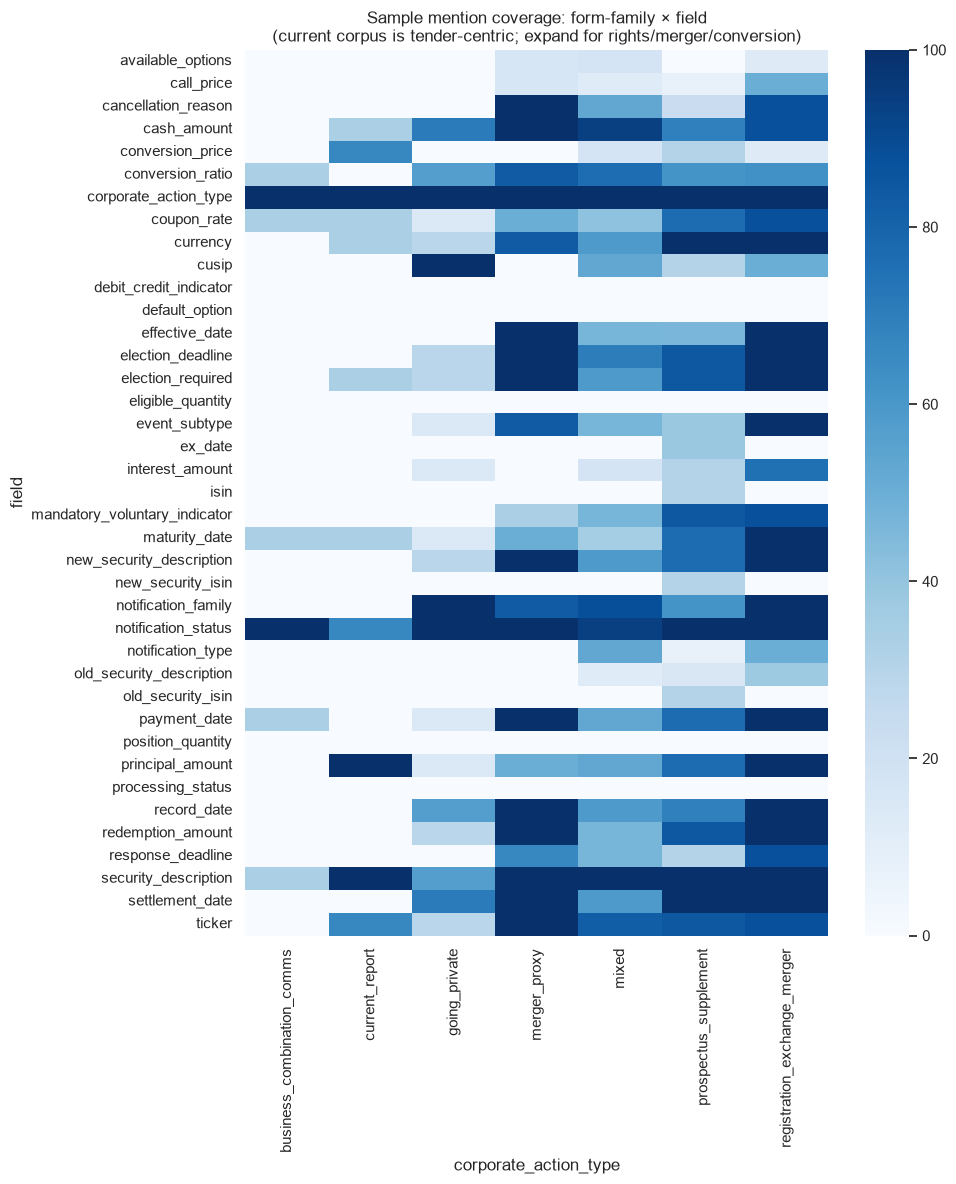

In [42]:
sample_path = PROCESSED_DIR / 'content_sample.parquet'
if sample_path.exists():
    content_sample = pd.read_parquet(sample_path)
else:
    content_sample = sample_documents_for_content(docs, n_per_form=10)
    content_sample.to_parquet(sample_path, index=False)

print(content_sample.groupby(['form','status']).size())
coverage = analyze_schema_coverage(docs, events, content_sample)
print(coverage['note'])

mvp = recommend_mvp_design(docs, events, coverage['schema_coverage'])
catalog = mvp['datastore_field_catalog']
display(catalog[['field','source_class','datastore_role','in_v1_benchmark','public_coverage_pct','relevant_mvp_types']])

fig = plot_schema_coverage_by_ownership(coverage['schema_coverage']); plt.show()
fig = plot_field_ownership_counts(coverage['schema_coverage']); plt.show()
fig = plot_notification_completeness(catalog); plt.show()
fig = plot_benchmark_field_coverage(coverage['schema_coverage'], BENCHMARK_FIELDS_V1); plt.show()
fig = plot_event_type_coverage_heatmap(coverage['event_type_coverage']); plt.show()


## 5. Temporal / amendment readiness (versioned event history)

Lifecycle: `initial → amendment(s) → completed/cancelled` — never overwrite prior versions.

### What the next cell outputs
1. Printed amendment stats (share of events with `/A`, etc.)
2. **Three small histograms** (`plot_mvp_amendment_readiness`) — filings/event, amendments/event, event span (days)
3. Preview table of MVP events
4. CSV: `mvp_preferred_events.csv`

### Why histograms (not a single summary number)
- **Claim:** tender events are multi-document and amendment-dense — the datastore must version history
- **Geometry:** distribution shape (skew, long tail) matters for product design; a mean alone hides that
- Three panels = three claims (volume of filings, amendment load, calendar span) — avoid overplotting on one axis



Events with amendments: 3214 (22.14%)
MVP preferred events: 272 | simple amend eval: 98 | complex: 183


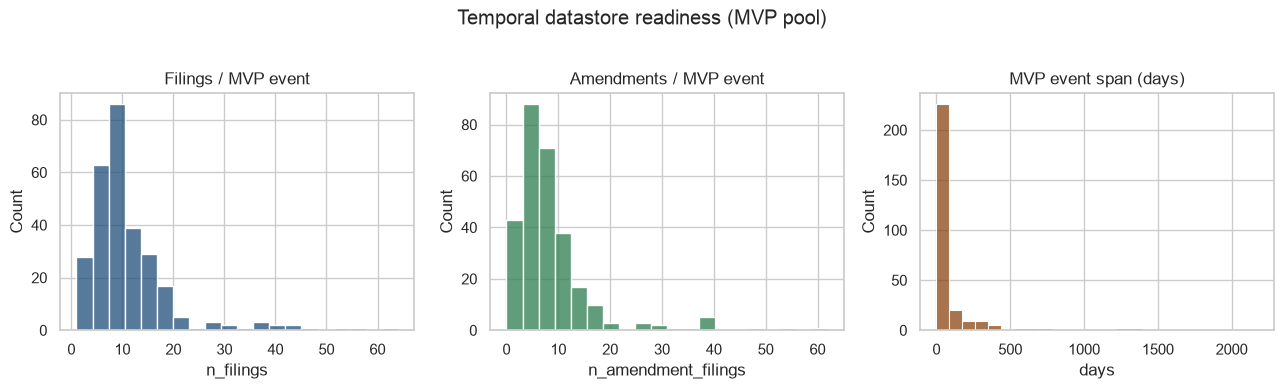

,event_id,primary_entity,primary_form_family,mvp_event_type_provisional,n_filings,n_amendment_filings,n_documents,event_span_days,has_14d9,in_mvp_preferred,amendment_eval_band
5577,005-02933,"VOLT INFORMATION SCIENCES, INC.",mixed,tender_offer,10,8,23,31,True,True,complex
5579,005-06295,VECTOR GROUP LTD,mixed,tender_offer,9,7,21,33,True,True,complex
5581,005-09319,AVX Corp,mixed,tender_offer,11,8,25,28,True,True,complex
5582,005-09915,EVANS & SUTHERLAND COMPUTER CORP,mixed,tender_offer,8,5,28,45,True,True,simple
5583,005-12061,HP INC,mixed,tender_offer,7,4,18,35,True,True,simple
5586,005-12857,"ADAMS NATURAL RESOURCES FUND, INC.",mixed,tender_offer,14,9,49,118,True,True,complex
5587,005-18240,CSS INDUSTRIES INC,mixed,tender_offer,11,9,27,31,True,True,complex
5591,005-20723,CONTINENTAL MATERIALS CORP,mixed,tender_offer,14,11,37,62,True,True,complex
5596,005-30797,OVERSEAS SHIPHOLDING GROUP INC,mixed,tender_offer,9,7,43,30,True,True,complex
5599,005-31632,GOLDFIELD CORP,mixed,tender_offer,17,15,37,29,True,True,complex


In [43]:
amend = analyze_amendments(docs, events, content_sample)
print(f"Events with amendments: {amend['n_events_with_amendments']} ({amend['pct_events_with_amendments']}%)")
print(f"MVP preferred events: {mvp['mvp_preferred_count']} | simple amend eval: {mvp['amendment_eval_simple_count']} | complex: {mvp['amendment_eval_complex_count']}")
fig = plot_mvp_amendment_readiness(mvp['mvp_events']); plt.show()
display(mvp['mvp_events_preview'])


## 6. Ground-truth & missingness (for the notification datastore)

Do not treat all missing values the same: N/A vs absent vs parse gap vs BNY-internal.

### What the next cell outputs
1. **Missingness taxonomy table** — field → missingness class / source / GT class / evidence type
2. **Benchmark subset table** — GT expectations for v1 fields
3. **Ground-truth recommendations table** — what to annotate vs derive vs leave internal
4. CSV: `missingness_taxonomy.csv`

### Why tables (not charts)
These rows are **decision labels** for annotation policy. A chart would force a false numeric scale onto categorical advice. Tables support stakeholder review line-by-line.



In [44]:
miss = classify_missingness(coverage['schema_coverage'], coverage['event_type_coverage'])
gt = ground_truth_recommendations(coverage['schema_coverage'])
display(miss.head(40))
display(catalog[catalog['in_v1_benchmark']][['field','datastore_role','ground_truth_class','public_coverage_pct','relevant_mvp_types']])
display(gt.head(25))
print('Manual annotation priorities:')
for p in mvp['manual_annotation_priorities']:
    print(' -', p)


,field,group,public_coverage_pct,missingness_class,source_class,ground_truth_class,evidence_type
0,notification_family,notification_metadata,75.44,sometimes_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
1,notification_type,notification_metadata,24.56,sometimes_present_in_public_sample,derived_from_public,requires_manual_annotation,inferred_regex_presence
2,notification_status,notification_metadata,96.49,usually_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
3,processing_status,notification_metadata,0.00,internal_bny_only,bny_internal_only,cannot_evaluate_from_public,internal_only
4,mandatory_voluntary_indicator,notification_metadata,49.12,sometimes_present_in_public_sample,public_document_extractable,requires_manual_annotation,inferred_regex_presence
5,security_description,security,100.00,usually_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
6,isin,security,7.02,likely_relevant_but_rarely_detected,public_document_extractable,requires_manual_annotation,inferred_regex_presence
7,cusip,security,42.11,sometimes_present_in_public_sample,public_document_extractable,requires_manual_annotation,inferred_regex_presence
8,ticker,security,75.60,sometimes_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
9,currency,security,68.42,sometimes_present_in_public_sample,public_document_extractable,weak_heuristic,inferred_regex_presence


,field,datastore_role,ground_truth_class,public_coverage_pct,relevant_mvp_types
2,notification_status,derive_from_public,weak_heuristic,96.49,"tender_offer,exchange_offer,rights_issue,merger,conversion"
5,security_description,extract_from_public,weak_heuristic,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
7,cusip,annotate_then_store,requires_manual_annotation,42.11,"tender_offer,exchange_offer,rights_issue,merger,conversion"
8,ticker,extract_from_public,weak_heuristic,75.60,"tender_offer,exchange_offer,rights_issue,merger,conversion"
12,corporate_action_type,derive_from_public,strong_automatic,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
23,conversion_ratio,annotate_then_store,requires_manual_annotation,63.16,"tender_offer,exchange_offer,rights_issue,merger,conversion"
28,available_options,annotate_then_store,requires_manual_annotation,8.77,"tender_offer,exchange_offer,rights_issue,merger,conversion"
30,election_deadline,annotate_then_store,requires_manual_annotation,68.42,"tender_offer,exchange_offer,rights_issue,merger,conversion"
31,response_deadline,annotate_then_store,requires_manual_annotation,40.35,"tender_offer,exchange_offer,rights_issue,merger,conversion"
37,cash_amount,exclude_or_investigate,cannot_evaluate_from_public,77.19,"tender_offer,exchange_offer,rights_issue,merger,conversion"


,field,group,public_coverage_pct,ground_truth_class,difficulty,benchmark_recommendation,evidence_type
26,call_price,conversion_exchange,14.04,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
24,conversion_price,conversion_exchange,17.54,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
22,new_security_isin,conversion_exchange,7.02,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
19,old_security_description,conversion_exchange,12.28,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
20,old_security_isin,conversion_exchange,7.02,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
28,available_options,election_response,8.77,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
29,default_option,election_response,0.00,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
1,notification_type,notification_metadata,24.56,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
6,isin,security,7.02,requires_manual_annotation,low,annotate_later_or_event_type_specific,inferred_regex_presence
16,ex_date,event,8.77,cannot_evaluate_from_public,high,exclude_from_public_benchmark,inferred_regex_presence


Manual annotation priorities:
 - CUSIP / security description (normalized)
 - Offer / exchange / subscription consideration
 - Expiration / election / withdrawal deadlines
 - Available options + default option (esp. mergers & rights)
 - Exchange / conversion ratios and prices
 - Material amendment field changes
 - notification_type mapping (BNY taxonomy vs SEC form)
 - Event-type labels for exchange vs cash tender inside Schedule TO


## 7. Splits (event-level only)

Never put an event's initial filing in train and its amendment in test.

### What the next cell outputs
1. **Leakage-risk table** — documented failure modes if you split at filing/hit level
2. **Split table** — event-level train/val/test style allocation for the MVP pool
3. Printed split policy text

### Why tables
Split policy is a **constraint list**, not a distribution to decorate. Showing risks as rows keeps the “do not do this” claims explicit for reviewers.



In [45]:
quality = analyze_data_quality(docs, events)
display(quality['leakage_risks'])
display(mvp['split_table'])
print(mvp['split_policy'])
print('Pipeline:', mvp['mvp_pipeline'])


,risk,affected_events,affected_documents,recommendation
0,document_level_random_split,10998,193731.0,"Split by event_id (SEC file number), not by document/accession."
1,issuer_repeated_across_splits,3298,NaN,Consider issuer/CIK-aware splits for generalization tests.
2,weak_event_key_without_file_num,0,0.0,Manually review fallback event keys before amendment evaluation.


,split,target_fraction,approx_events_if_tender_mvp
0,train,0.70,200
1,validation,0.15,43
2,test,0.15,43


Always split by event_id (SEC file number / future event key). Never by document. Keep all amendments with the parent event. Optionally hold out entire issuers (CIK) for a generalization fold.
Pipeline: public SEC docs (by event type) → versioned event datastore → field extraction + citations → BNY-shaped notification draft → amendment deltas → escalate gaps / internal placeholders


## 8. Persist datastore-oriented artifacts

### What the next cell outputs
Writes CSVs used by preprocess / reporting (schema coverage, event-type coverage, missingness, funnel, taxonomy, preferred events, figures already saved under `figures/`).

### Why no chart here
This cell is **I/O only** — persistence for reproducibility. Visualization belongs in the analysis sections above.



In [46]:
coverage['schema_coverage'].to_csv(OUTPUTS / 'schema_coverage.csv', index=False)
coverage['event_type_coverage'].to_csv(OUTPUTS / 'event_type_coverage.csv', index=False)
catalog.to_csv(OUTPUTS / 'datastore_field_catalog.csv', index=False)
mvp['mvp_events'].to_csv(OUTPUTS / 'mvp_events.csv', index=False)
mvp['corpus_gaps'].to_csv(OUTPUTS / 'mvp_corpus_gaps.csv', index=False)
gt.to_csv(OUTPUTS / 'ground_truth_feasibility.csv', index=False)
miss.to_csv(OUTPUTS / 'missingness_taxonomy.csv', index=False)
events.to_csv(OUTPUTS / 'events.csv', index=False)
tables['summary'].to_csv(OUTPUTS / 'dataset_overview.csv', index=False)

# Copy figures into outputs/
for p in FIGURES_DIR.glob('mvp_*.png'):
    (OUTPUTS / 'figures' / p.name).write_bytes(p.read_bytes())

print('Primary outputs:', OUTPUTS)
print('Or: python scripts/run_eda.py')


Primary outputs: /Users/kedarvaidya/Desktop/BNY-Capstone-Project/outputs
Or: python scripts/run_eda.py


# Implications for MVP Design

1. **Event types:** Target all five — tender, exchange, rights, merger, conversion. **Ship v1 on third-party tenders (+ 14D9)**; phase 2+ expands corpus per `mvp_build_order.csv`.
2. **Public-reliable fields (tender):** `corporate_action_type`, `security_description`, `cusip`, deadlines, coarse `notification_status`, offer-price proxy.
3. **Internal placeholders:** `processing_status`, `position_quantity`, `eligible_quantity`, `debit_credit_indicator`, client `cash_amount`.
4. **Manual GT needed:** options/default option, normalized IDs, ratios/prices, amendment deltas, BNY `notification_type`.
5. **Amendment histories:** dense for tenders (~97% have `/A`); reuse pattern for other types once collected.
6. **v1 extraction benchmark:** see `BENCHMARK_FIELDS_V1` (+ type-specific ratio/options fields as types come online).
7. **Preprocess path (built):** inventory → download → cleanup → segment → GLiNER → assemble produces citable Concise Reps on gold TOs. Stage-by-stage demo with raw→output samples: **§9** and [`preprocess_stage_inspect.ipynb`](preprocess_stage_inspect.ipynb).
8. **Sufficiency today:** Concise Rep is enough to *start* a public-only agent; curated `event_field_values` + notification draft still to build ([`schema.md`](../docs/schema.md)). Full multi-type MVP — still **blocked on corpus expansion** for rights/merger/conversion.
9. **Data gaps:** collect S-4, DEFM14A/PREM14A, SC 13E-3, 424B*, targeted 8-K conversion/rights notices; reclassify exchange offers inside Schedule TO.


## 9. Preprocess MVP findings (stage path — presentable)

The EDA above scopes **what** public SEC can support. The preprocess path below proves we can turn preferred tender filings into a **citable Concise Representation** for an agent.

**Deep-dive slides:** [`preprocess_stage_inspect.ipynb`](preprocess_stage_inspect.ipynb) — raw → clean → segments → GLiNER → Concise Rep, with stage reasoning and principle-aligned PNGs under `figures/preprocess/`.

```text
inventory → download → cleanup → segment → GLiNER → assemble
```

### What the next cell outputs
- Printed counts: Concise Reps on disk, quality-gate pass rate, total candidate facts
- **Preview table** of events with top-1 `offer_price` / `expiration` / `offeror` and `gate_ok`

### Why a table here (charts live in the inspect notebook)
This EDA section is a **live status strip** for the narrative. The inspect notebook owns the story-first figures (cohort mix, event-level funnel, gate pass rate, top-1 field readiness) so each claim gets its own chart instead of a cramped multi-panel.

| Inspect notebook figure | Claim | Why that chart |
|---|---|---|
| Cohort mix bars | ~97% inventoried events are gold | Highlight gold; mute the rest; direct labels |
| Event funnel bars | Almost all inventoried events reach Concise Rep | Same unit (events) every stage; ordinal order |
| Quality-gate bars | ~90% pass upstream gates | Encode pass vs fail directly |
| Top-1 field readiness | Price/date/offeror usually present after ranking | % of events — not raw span counts |

SEC-only agent contract: [`docs/schema.md`](../docs/schema.md). Pipeline LLD: [`docs/lld-preprocess-pipeline.md`](../docs/lld-preprocess-pipeline.md).



In [47]:
# Live cohort snapshot from preprocess artifacts (for the EDA narrative)
from pathlib import Path
import json
import sys

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.preprocess.quality_gates import check_event_rep
from src.preprocess.store import ArtifactStore, DEFAULT_PREPROCESS_ROOT

_store = ArtifactStore("tender", DEFAULT_PREPROCESS_ROOT)
_rows = []
for _d in sorted((_store.path_root / "events").iterdir()):
    if not _d.is_dir():
        continue
    _rep_p = _d / "concise" / "event_rep.json"
    if not _rep_p.exists():
        continue
    _rep = json.loads(_rep_p.read_text())
    _inv = json.loads((_d / "inventory.json").read_text()) if (_d / "inventory.json").exists() else {}
    _g = check_event_rep(_rep)
    _rows.append({
        "event_id": _d.name,
        "entity": _inv.get("primary_entity"),
        "n_facts": len(_rep.get("candidate_facts") or []),
        "top_offer_price": _g["checks"].get("top1_offer_price"),
        "top_expiration": _g["checks"].get("top1_expiration_date"),
        "top_offeror": _g["checks"].get("top1_offeror"),
        "gate_ok": _g["ok"],
    })

_pre = pd.DataFrame(_rows)
if _pre.empty:
    print("No Concise Rep artifacts yet — run: python scripts/run_preprocess.py --path tender --from-stage download --cohort gold --pending-only --progress")
else:
    print(f"Concise Reps: {len(_pre)} | gates pass: {_pre['gate_ok'].sum()} | facts: {_pre['n_facts'].sum()}")
    display(_pre.head(10))

Concise Reps: 29 | gates pass: 26 | facts: 2175


,event_id,entity,n_facts,top_offer_price,top_expiration,top_offeror,gate_ok
0,005-02933,"VOLT INFORMATION SCIENCES, INC.",69,$6.00,"March 12, 2022","AmericanCyberSystems, Inc.",True
1,005-06295,VECTOR GROUP LTD,101,$15.00,"September 16, 2024",Vector Group Ltd.,True
2,005-09319,AVX Corp,40,$21.75,"March 2, 2020",KYOCERA CORPORATION,True
3,005-09915,EVANS & SUTHERLAND COMPUTER CORP,110,"$250,000","February 9, 2020",ELEVATE ENTERTAINMENT INC.,True
4,005-12061,HP INC,48,$18.40,"APRIL 21, 2020",Xerox Holdings Corporation,True
5,005-12857,"ADAMS NATURAL RESOURCES FUND, INC.",29,"$70,000,000.00",NaN,"Ancora Advisors, LLC",False
6,005-18240,CSS INDUSTRIES INC,131,"$3,000,000","February 28, 2020","IG Design Group Americas, Inc.",True
7,005-20723,CONTINENTAL MATERIALS CORP,33,$9.50,"February 18, 2020",Bee Street Holdings LLC,True
8,005-30797,OVERSEAS SHIPHOLDING GROUP INC,40,$8.50,"July 9, 2024","SALTCHUK\nRESOURCES, INC.",True
9,005-31632,GOLDFIELD CORP,90,$125 million,"November 30, 2020","FR UTILITY SERVICES MERGER SUB, INC.",True
